In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Concatenate
from tensorflow.keras.models import Model
import pandas as pd
import numpy as np
import os
import glob
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


2025-09-11 15:48:36.406945: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-11 15:48:36.416312: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757598516.427992  202811 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757598516.431691  202811 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-11 15:48:36.443404: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:

# ----------------------------
# Config
# ----------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50
LR = 1e-3
DROPOUT_RATE = 0.5
N_CLASSES = 3   # Normal, Benign, Malignant


In [3]:

# ----------------------------
# Load & Merge Metadata
# ----------------------------
excel_path = "CDD-CESM/Radiology-manual-annotations.xlsx"
sheets = pd.read_excel(excel_path, sheet_name=None)

df_merged = None
for name, sheet in sheets.items():
    if "Image_name" not in sheet.columns:
        continue
    if df_merged is None:
        df_merged = sheet
    else:
        df_merged = pd.merge(df_merged, sheet, on="Image_name", how="outer", suffixes=("", f"_{name}"))
        for col in df_merged.columns:
            if col.endswith(f"_{name}"):
                base_col = col.replace(f"_{name}", "")
                if base_col in df_merged.columns:
                    df_merged.drop(columns=[col], inplace=True)


In [4]:

# ----------------------------
# Load images & basic labels
# ----------------------------
image_root = "CDD-CESM/organized_images"
labels = ["benign", "malignant", "normal"]

rows = []
for label in labels:
    folder = os.path.join(image_root, label)
    for img_path in glob.glob(os.path.join(folder, "*")):
        img_name = os.path.basename(img_path)
        rows.append({
            "Image_name": img_name,
            "label": label.capitalize(),  # "Benign", "Malignant", "Normal"
            "filepath": img_path
        })

df_images = pd.DataFrame(rows)

# Merge metadata with images if needed
df = pd.merge(df_images, df_merged, on="Image_name", how="left")


In [5]:

# ----------------------------
# Tabular features
# ----------------------------
exclude_cols = ["Image_name", "filepath", "Diagnosis", "label"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X_tab = df[feature_cols].copy()
for col in X_tab.select_dtypes(include=["object"]).columns:
    X_tab[col] = X_tab[col].astype(str).fillna("NA")
    le = LabelEncoder()
    X_tab[col] = le.fit_transform(X_tab[col])
X_tab = X_tab.fillna(0)
scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)


In [6]:

# ----------------------------
# Labels
# ----------------------------
if "Diagnosis" in df.columns:
    y = df["Diagnosis"].astype(str).str.capitalize()
else:
    y = df["label"].astype(str).str.capitalize()

label_map = {"Normal":0, "Benign":1, "Malignant":2}
y_numeric = y.map(label_map).values
y_onehot = tf.keras.utils.to_categorical(y_numeric, num_classes=N_CLASSES)


In [7]:

# ----------------------------
# Train/Validation Split
# ----------------------------
df["tabular"] = list(X_tab)
df["label_onehot"] = list(y_onehot)

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=y_numeric
)


In [8]:

# ----------------------------
# TF Dataset
# ----------------------------
def load_image(path, tab, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
    return {"raw_image": img, "tabular": tab}, label

def make_dataset(df, augment=False):
    filepaths = df["filepath"].values
    X_tab = np.stack(df["tabular"].values)
    y_labels = np.stack(df["label_onehot"].values)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, X_tab, y_labels))
    ds = ds.map(lambda p, t, l: load_image(p, t, l, augment), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.shuffle(len(df))
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset = make_dataset(train_df, augment=True)
val_dataset = make_dataset(val_df, augment=False)


2025-09-11 15:48:38.667624: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:

# ----------------------------
# Build Model

# ----------------------------
# Image branch (custom CNN)
# ----------------------------
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
raw_in = Input(shape=(224, 224, 3), name="raw_image")

c = Conv2D(32, (3,3), activation="relu", padding="same")(raw_in)
c = MaxPooling2D((2,2))(c)

c = Conv2D(64, (3,3), activation="relu", padding="same")(c)
c = MaxPooling2D((2,2))(c)

c = Conv2D(128, (3,3), activation="relu", padding="same")(c)
c = MaxPooling2D((2,2))(c)

c = Flatten()(c)
c = Dense(128, activation="relu")(c)
c = Dropout(0.5)(c)

# Tabular branch
tab_in = Input(shape=(X_tab.shape[1],), name="tabular")
t = Dense(128, activation="relu")(tab_in)
t = Dropout(0.3)(t)
t = Dense(64, activation="relu")(t)

# Fusion
fusion = Concatenate()([c, t])
fusion = Dense(128, activation="relu")(fusion)
fusion = Dropout(0.4)(fusion)
out = Dense(N_CLASSES, activation="softmax")(fusion)

model = Model(inputs=[raw_in, tab_in], outputs=out)



In [10]:

# ----------------------------
# Compile
# ----------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)



In [11]:

# ----------------------------
# Callbacks
# ----------------------------
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.1, patience=5, verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]


In [12]:

# ----------------------------
# Train
# ----------------------------
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 536ms/step - accuracy: 0.3454 - loss: 1.1200 - precision: 0.3504 - recall: 0.0200 - val_accuracy: 0.3766 - val_loss: 1.0935 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 627ms/step - accuracy: 0.3635 - loss: 1.1002 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3766 - val_loss: 1.0944 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 642ms/step - accuracy: 0.3873 - loss: 1.0950 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.4115 - val_loss: 1.0923 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 639ms/step - accuracy: 0.3785 - loss: 1.0950 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3940 - val_loss: 1.0911 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learni

In [13]:

# ----------------------------
# Evaluate
# ----------------------------
loss, acc, prec, rec = model.evaluate(val_dataset)
print(f"Validation Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}, Recall: {rec:.4f}")


26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.4698 - loss: 1.0637 - precision: 0.4771 - recall: 0.1055
Validation Accuracy: 0.4414
Precision: 0.4302, Recall: 0.0923


In [14]:

# ----------------------------
# Save Model
# ----------------------------
model.save("cdd_fusion_model_safe.h5")


2025-09-11 17:59:19.455507: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step


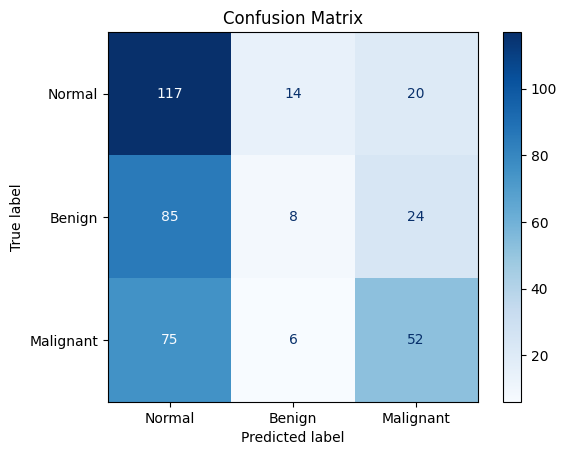

In [15]:

# ----------------------------
# Confusion Matrix
# ----------------------------
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
y_pred_probs = model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_true, axis=1)
cm = confusion_matrix(y_true_classes, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Benign", "Malignant"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
